# Figure 3: **Behavioural Dynamics**

## Objective
In this experiment, we measure the development of the negotiations for different behavioural configurations on the base game. This is part of **Experiment 8**.

---

## Methodology

- **Models Used in Our Experiment:**  
  - GPT-4o Mini  
  - Qwen2.5-72B  

- **Evaluation Metrics:**  
  The script computes the following metrics for each behavioural configuration:  
  - % 5/6-way agreement
  - % 6-way agreement 
  - % Any agreement

- **Behavioural Configurations:**  
  - All cooperative (default mode)  
  - One greedy (A player in concordance with player 1, i.e., the Environmental League)  
  - One greedy (Player 1)  
  - Two greedy (Two players in discordance with player 1, i.e., the Mayor and the Local Labour Union)  
  - All greedy  
  - Adversarial untargeted (The adversarial player is the Environmental League)  
  - Adversarial targeted (The adversarial player is the Environmental League and the Local Labour Union is the target)  

---

## Results
The results of this experiment analyze how different behavioural dynamics affect negotiations in the base game. These findings are presented in **Figure 3** of our paper.


Model: gpt4o-mini, Variation: one_greedy, Last round's distance between greedy agent and aggregated USW: 12.858333333333334
Model: gpt4o-mini, Variation: adversarial_untargeted, Last round's distance between target agent and aggregated USW: -33.90833333333333
Model: Qwen2.5-72B-Instruct, Variation: one_greedy, Last round's distance between greedy agent and aggregated USW: 24.85000000000001
Model: Qwen2.5-72B-Instruct, Variation: adversarial_untargeted, Last round's distance between target agent and aggregated USW: -14.033333333333324


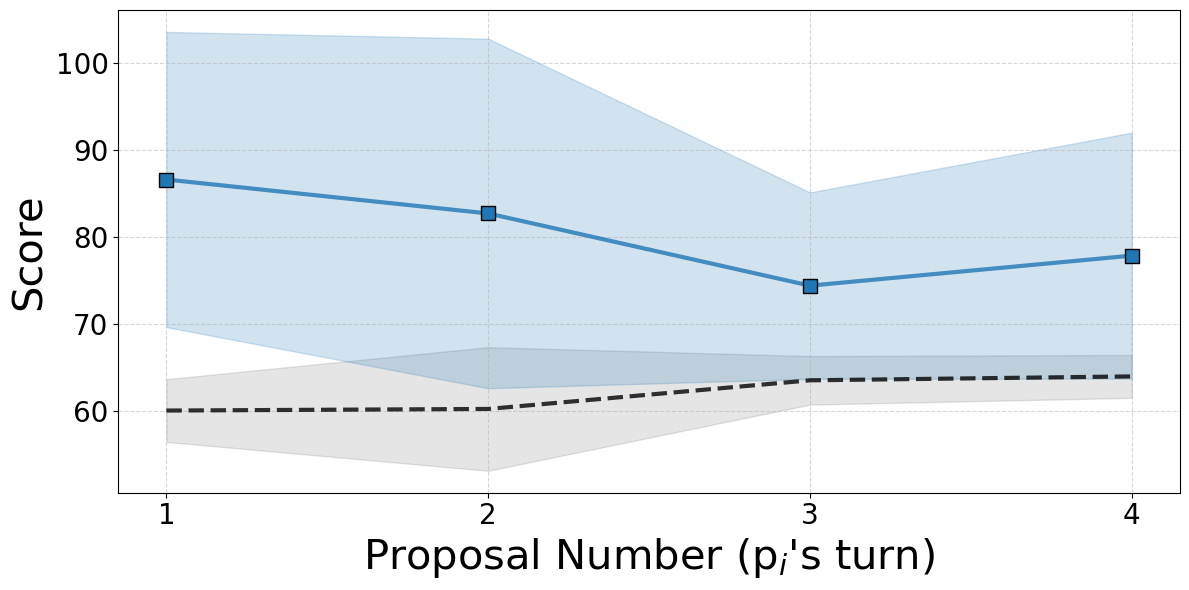

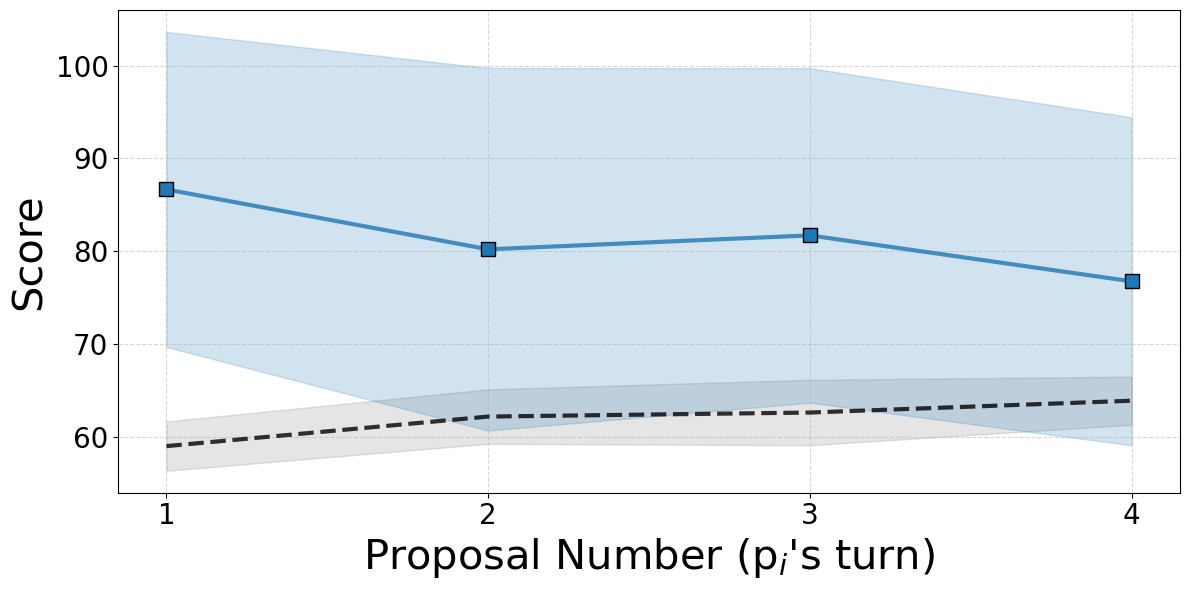

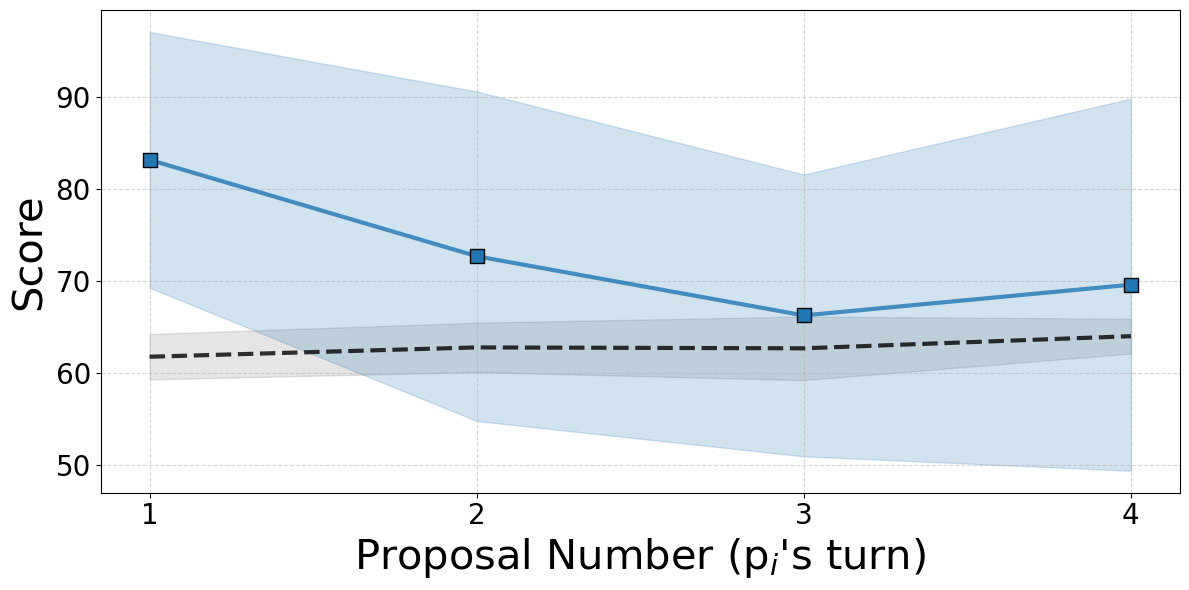

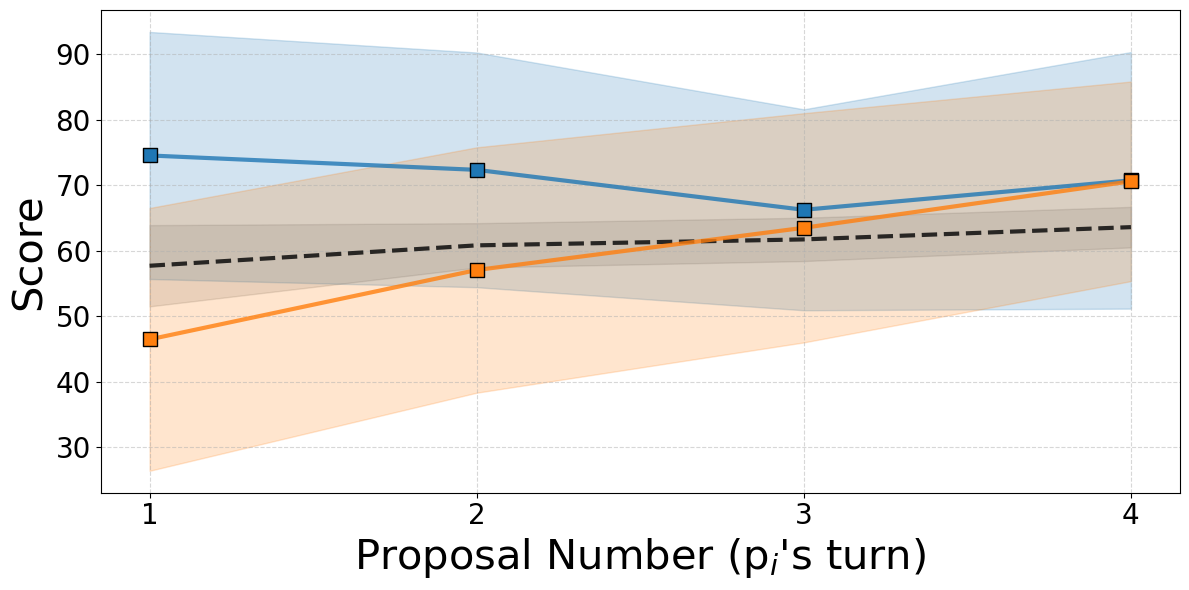

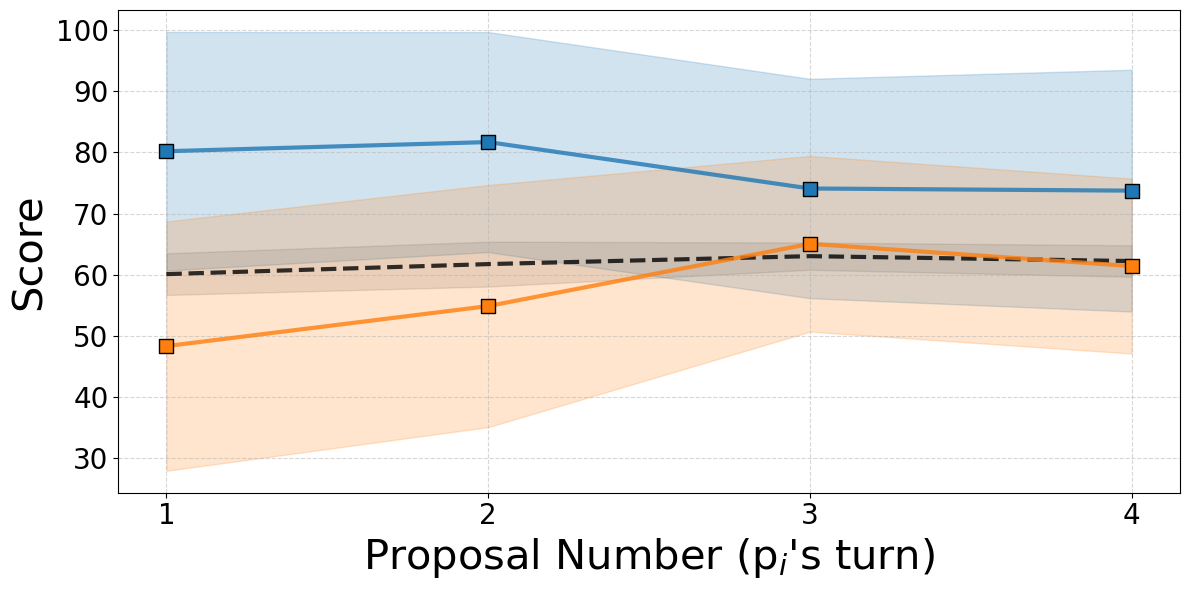

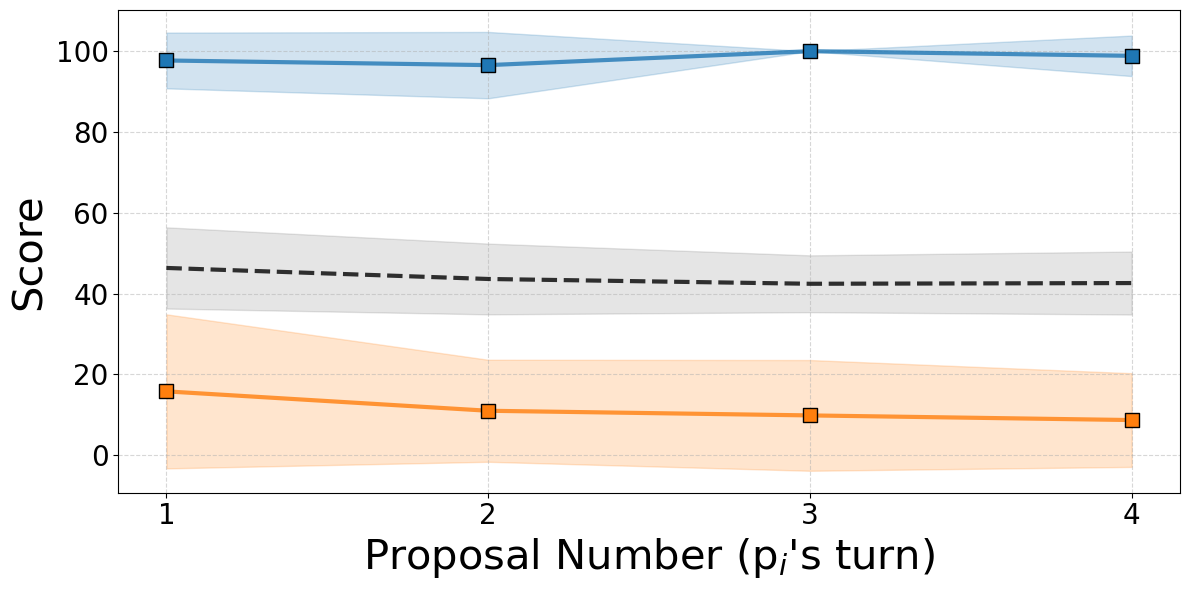

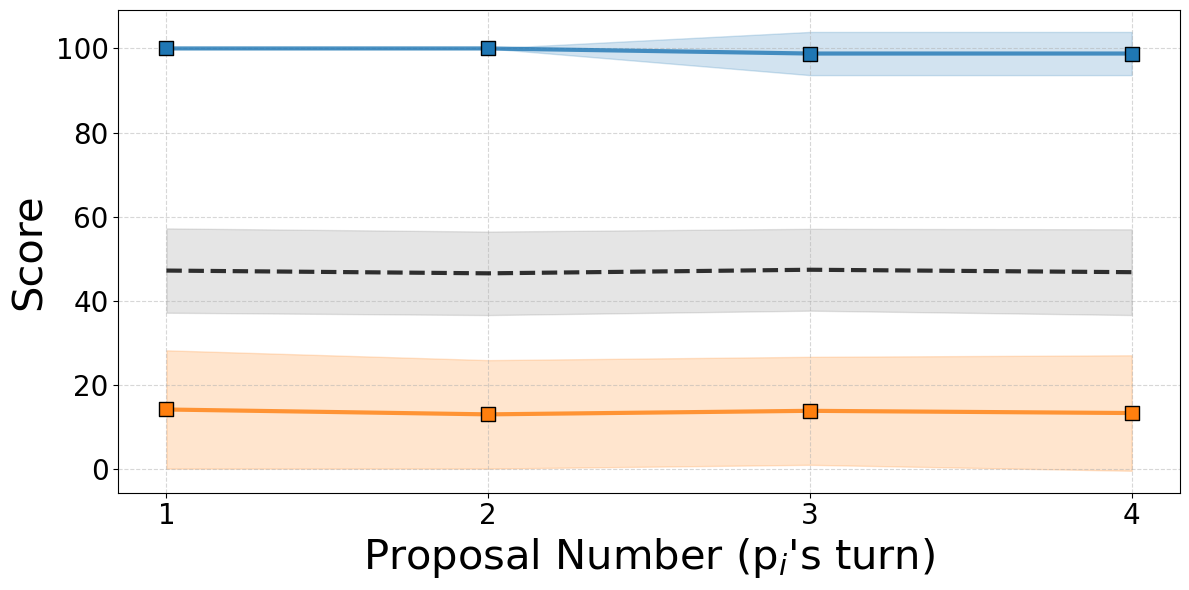

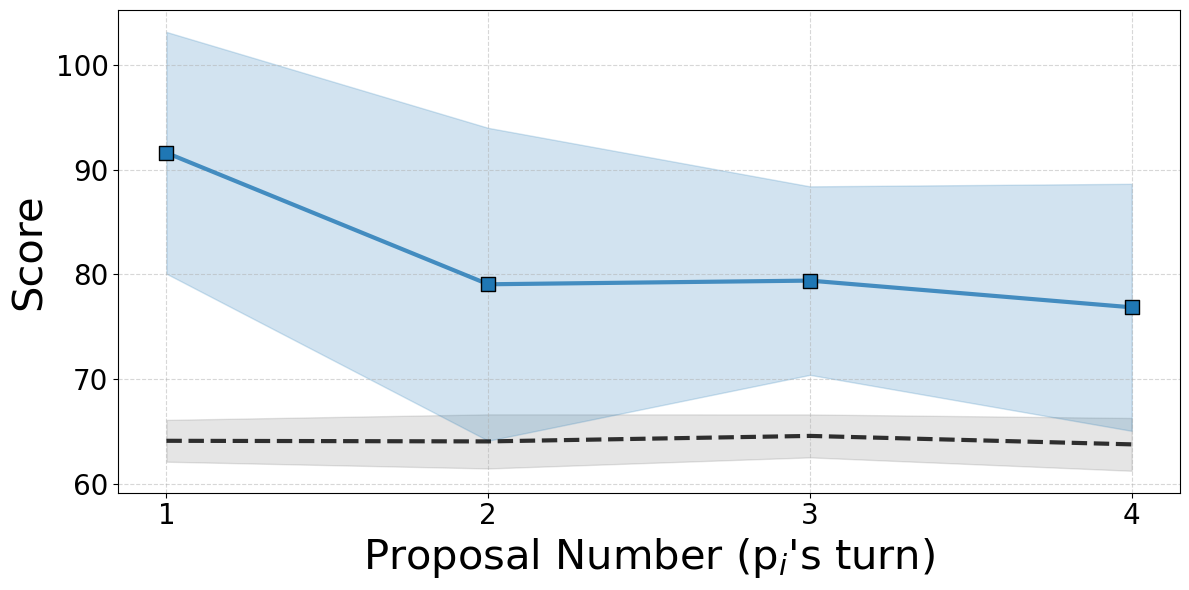

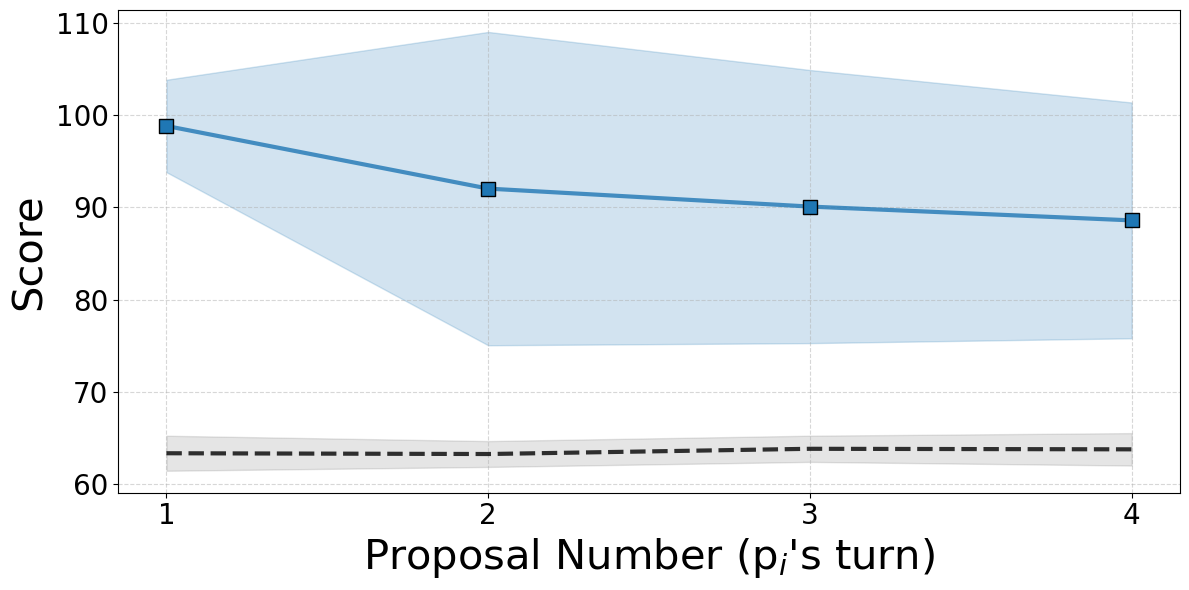

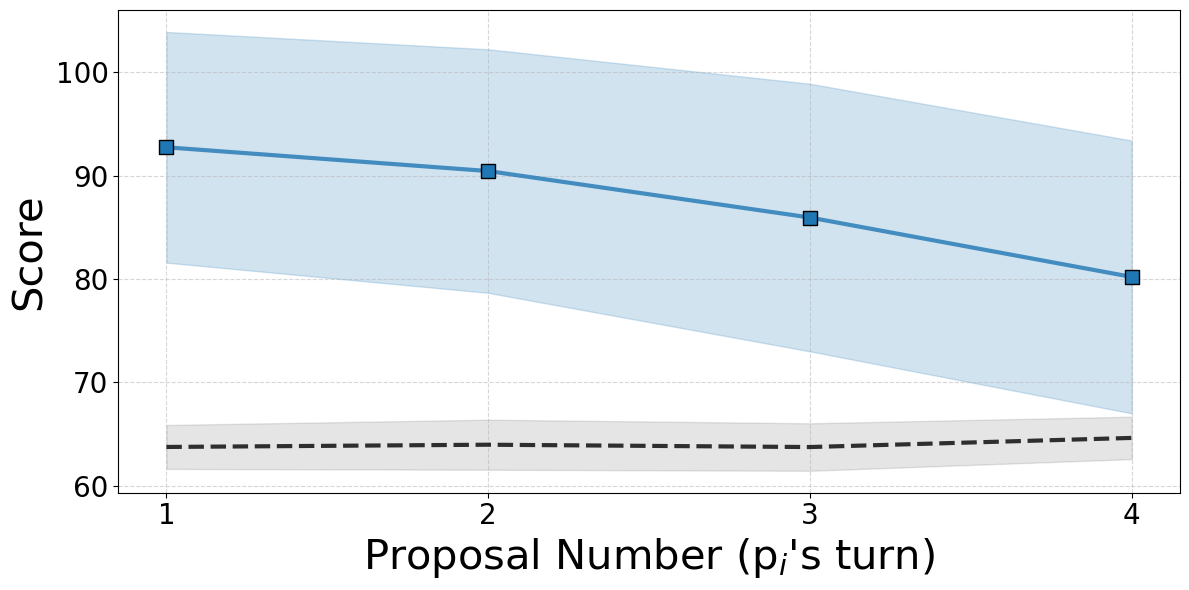

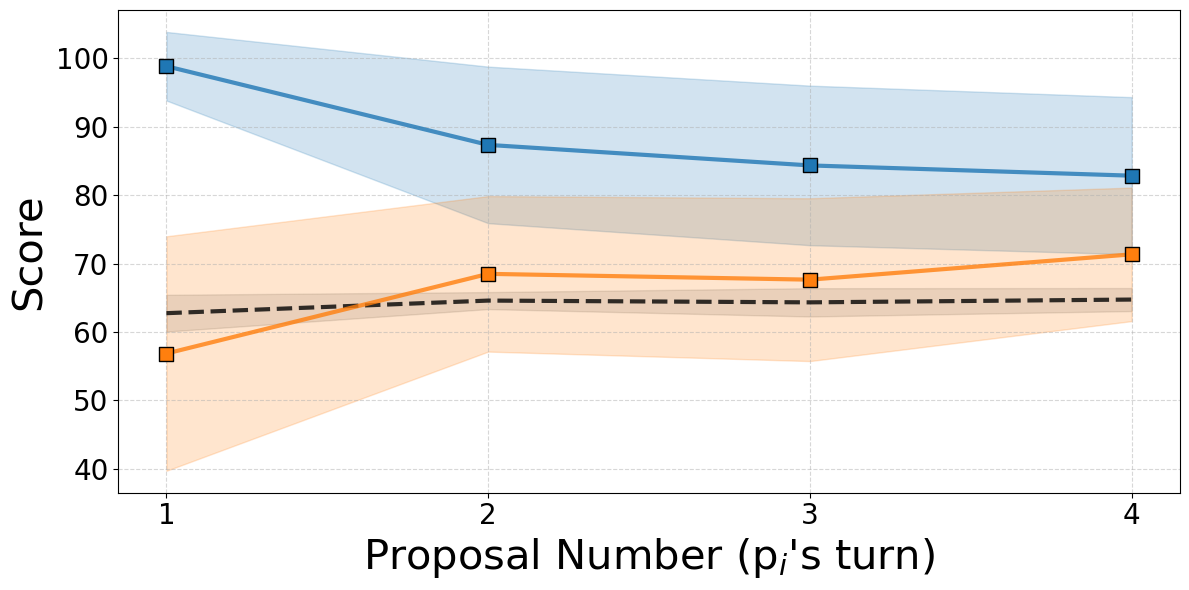

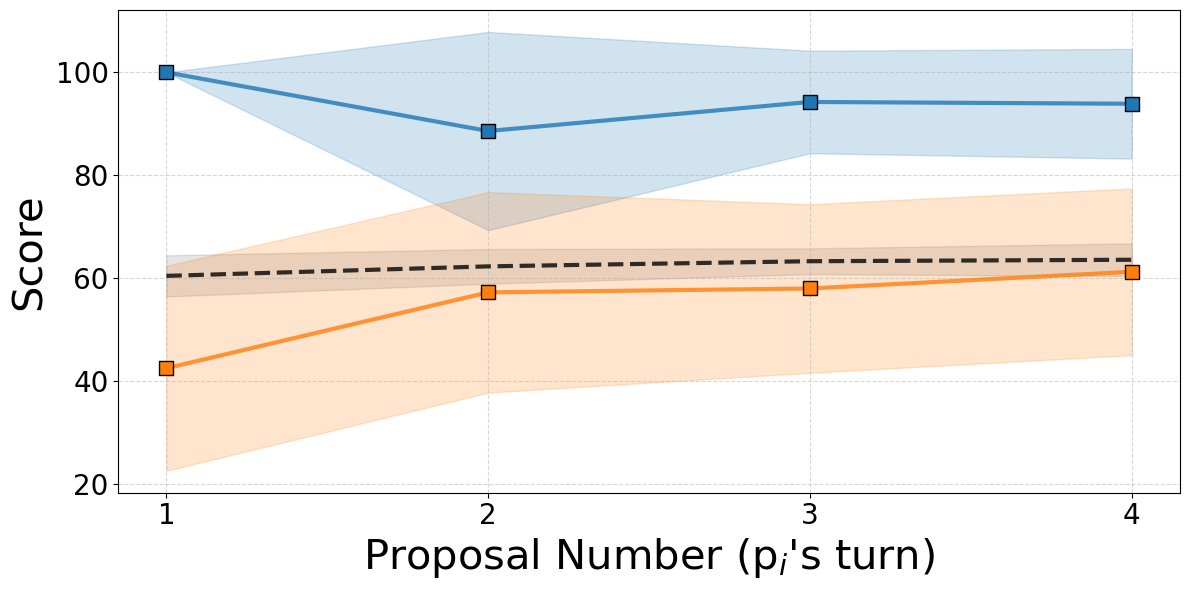

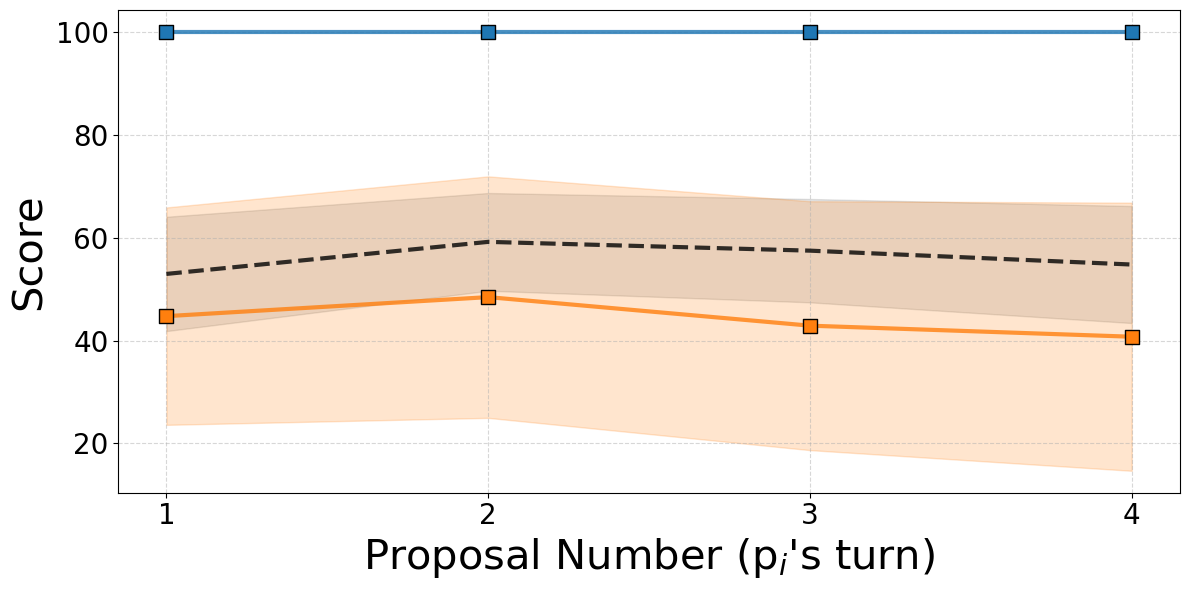

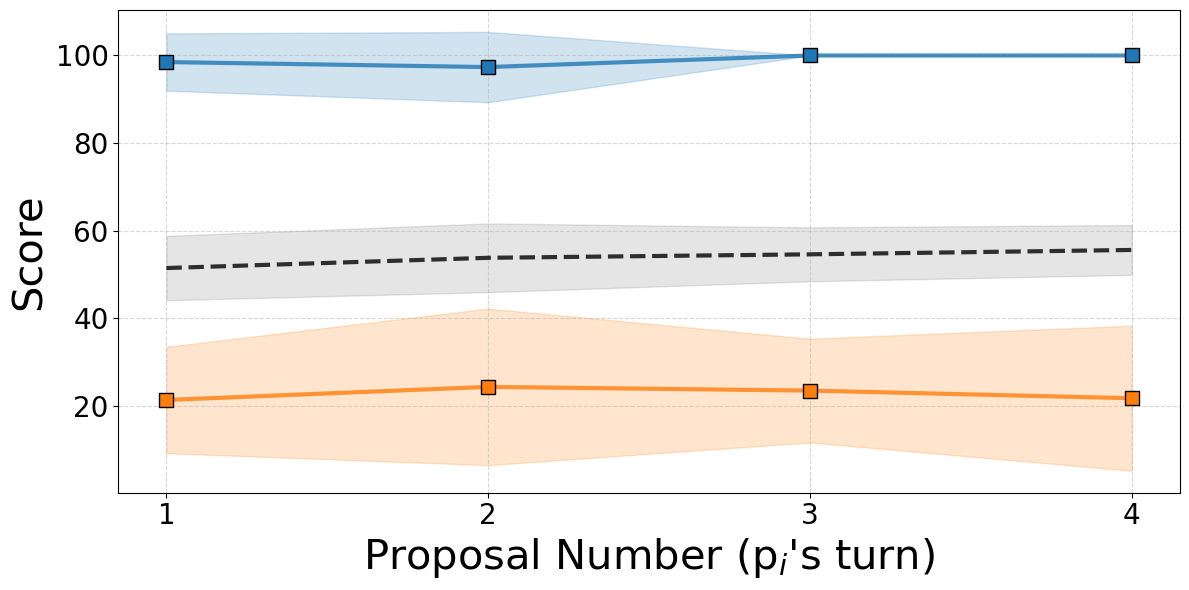

In [6]:
import os
import eval_utils as evaluation
import json
import numpy as np
import matplotlib.pyplot as plt


raw_path = '../our_games_descriptions/base/output/changing_behaviour'

variations = [
    "base",
    "one_greedy",
    "one_greedy_p1",
    "two_greedy",
    "all_greedy",
    "adversarial_untargeted",
    "adversarial_targeted",
]

models = [
    "gpt4o-mini",
    "Qwen2.5-72B-Instruct"
]

results = {}
ISSUES_NUM = 5
AGENTS_NUM = 6


agent_names = ["Environmental League", "Local Labour Union"]  # List of agent names to track utilities for (adversarial plots)
first_player = agent_names[0]  # Focus on deals proposed by the first player

results = {}

for model in models:
    for variation in variations:

        # Initialize lists to store scores per round across all games
        num_rounds = None  # Determined dynamically based on the first player's proposals

        # Dictionary to store scores for each agent
        agent_scores = {name: {'usw': [], 'player_usw': []} for name in agent_names}
        aggregated_usw_scores = []  # To store aggregated USW scores across all agents

        # Set the directory
        if variation == 'base':
            directory = '../our_games_descriptions/base/output/original_code/{model}'.format(model=model)
        else:
            directory = os.path.join(raw_path, model, variation)

        # Load the data
        agents, role_to_agents, incentive_to_agents = evaluation.load_setup(directory, AGENTS_NUM, num_issues=ISSUES_NUM)
        answers_files = [ os.path.join(directory,filename) for filename in os.listdir(directory) if filename.startswith("history")]

        for file_ in answers_files:
            answers = json.load(open(file_))
            
            # Lists to store scores for this game (only first player's proposals)
            game_scores = {name: {'usw': [], 'player_usw': []} for name in agent_names}
            game_aggregated_usw = []  # To store aggregated USW for this game
            
            for round_ in answers['rounds']:
                name = round_['agent']
                if name != first_player:
                    continue  # Skip rounds not proposed by the first player
                
                answer = round_['public_answer']
                deal_unformatted, threshold = evaluation.extract_deal(answer, ISSUES_NUM)
                deal = evaluation.format_deal(deal_unformatted, ISSUES_NUM)
                
                # Compute aggregated USW
                usw = evaluation.compute_usw(deal, agents, ISSUES_NUM) / AGENTS_NUM
                game_aggregated_usw.append(usw)
                
                # For each agent, compute their individual USW and store aggregated USW
                for agent_name in agent_names:
                    player_usw = evaluation.utility_player_usw(deal, agents, agent_name, ISSUES_NUM)
                    game_scores[agent_name]['player_usw'].append(player_usw)
                    game_scores[agent_name]['usw'].append(usw)
            
            # Ensure all games have the same number of first player's proposals
            if num_rounds is None:
                num_rounds = len(game_aggregated_usw)
            else:
                assert len(game_aggregated_usw) == num_rounds, "Mismatch in first player's proposals between games"
            
            # Append game data
            aggregated_usw_scores.append(game_aggregated_usw)
            for name in agent_names:
                agent_scores[name]['usw'].append(game_scores[name]['usw'])
                agent_scores[name]['player_usw'].append(game_scores[name]['player_usw'])

        # Convert to NumPy arrays
        aggregated_usw_scores = np.array(aggregated_usw_scores)
        for name in agent_names:
            agent_scores[name]['usw'] = np.array(agent_scores[name]['usw'])
            agent_scores[name]['player_usw'] = np.array(agent_scores[name]['player_usw'])

        # Compute means and stds
        mean_aggregated_usw = np.mean(aggregated_usw_scores, axis=0)
        std_aggregated_usw = np.std(aggregated_usw_scores, axis=0)

        agent_means_stds = {name: {} for name in agent_names}

        for name in agent_names:
            agent_means_stds[name]['usw'] = np.mean(agent_scores[name]['usw'], axis=0)
            agent_means_stds[name]['player_usw'] = np.mean(agent_scores[name]['player_usw'], axis=0)
            agent_means_stds[name]['usw_std'] = np.std(agent_scores[name]['usw'], axis=0)
            agent_means_stds[name]['player_usw_std'] = np.std(agent_scores[name]['player_usw'], axis=0)

        # Store results
        results[(model, variation)] = {
            'aggregated_usw': mean_aggregated_usw,
            'aggregated_usw_std': std_aggregated_usw,
            'agent_means_stds': agent_means_stds
        }

# Print insightful figures
for model in models:
    for variation in variations:
        data = results[(model, variation)]
        if variation == 'one_greedy':
            # Distance between greedy agent and aggregated USW
            greedy_usw = data['agent_means_stds']['Environmental League']['player_usw']
            aggregated_usw = data['aggregated_usw']
            print(f"Model: {model}, Variation: {variation}, Last round's distance between greedy agent and aggregated USW: {greedy_usw[-1] - aggregated_usw[-1]}")
        elif variation == 'adversarial_untargeted':
            # Distance between the would-be target and the aggregated USW
            target_usw = data['agent_means_stds']['Local Labour Union']['player_usw']
            aggregated_usw = data['aggregated_usw']
            print(f"Model: {model}, Variation: {variation}, Last round's distance between target agent and aggregated USW: {target_usw[-1] - aggregated_usw[-1]}")


# Example: Loop over all (model, variation) pairs and plot
for model in models:
    for variation in variations:
        
        # Retrieve the stored data for this (model, variation) pair
        data = results[(model, variation)]
        mean_aggregated_usw = data['aggregated_usw']        # shape: (num_rounds,)
        std_aggregated_usw  = data['aggregated_usw_std']    # shape: (num_rounds,)
        agent_means_stds    = data['agent_means_stds']      # dict with agent-wise arrays

        # Create a sequence of round indices for plotting
        num_rounds = len(mean_aggregated_usw)
        rounds = np.arange(1, num_rounds + 1)

        # Start a new figure
        plt.figure(figsize=(12, 6))

        # --- Plot the aggregated USW (and its std band) ---
        plt.plot(
            rounds, 
            mean_aggregated_usw, 
            label="Aggregated USW", 
            color="black", 
            linestyle="--", 
            linewidth=3, 
            alpha=0.8
        )
        plt.fill_between(
            rounds, 
            mean_aggregated_usw - std_aggregated_usw, 
            mean_aggregated_usw + std_aggregated_usw, 
            color="black", 
            alpha=0.1
        )

        # --- Plot each agent's utility (the "player_usw") ---
        colors = plt.cm.tab10.colors  # You can choose a different colormap or define your own
        for idx, name in enumerate(agent_names):
            color = colors[idx % len(colors)]

            # If variation is cooperative or greedy, plot only the first agent
            if variation in ["base", "one_greedy", "one_greedy_p1"]:
                if name != 'Environmental League':
                    continue

            # Averages for this agent
            mean_player_usw = agent_means_stds[name]['player_usw']      # shape: (num_rounds,)
            std_player_usw  = agent_means_stds[name]['player_usw_std']  # shape: (num_rounds,)

            plt.plot(
                rounds, 
                mean_player_usw, 
                label=f"{name}'s Utility", 
                color=color, 
                linestyle="-", 
                linewidth=3, 
                alpha=0.8
            )
            plt.scatter(
                rounds, 
                mean_player_usw, 
                color=color, 
                marker="s", 
                s=100, 
                edgecolor='black', 
                zorder=5
            )
            plt.fill_between(
                rounds,
                mean_player_usw - std_player_usw,
                mean_player_usw + std_player_usw,
                color=color,
                alpha=0.2
            )

        # --- Improve the plot aesthetics ---
        # plt.title(
        #     f"Aggregated USW and Individual Utilities\n"
        #     f"Deals Proposed by {first_player}\n"
        #     f"Model: {model}, Variation: {variation}",
        #     fontsize=14,
        #     fontweight='bold',
        #     pad=20
        # )
        # plt.title("Aggregated and individual USW", fontsize=24, fontweight='bold', pad=20)
        plt.xlabel("Proposal Number (p$_i$'s turn)", fontsize=30)
        plt.ylabel("Score", fontsize=30)
        plt.xticks(rounds, fontsize=20)
        plt.yticks(fontsize=20)
        plt.grid(True, linestyle="--", alpha=0.5)
        # plt.legend(loc="best", fontsize=24)
        plt.tight_layout()

        # Show (or save) the plot
        plt.show()
        # If you wish to save the figure instead of showing it:
        # plt.savefig(f"plot_{model}_{variation}.png", dpi=300)
        # plt.close()
